# PQC 종합 강의 노트북 — 4대 유형 비교 · 표준화 · 전환
## Post-Quantum Cryptography: Comparison, Standardization, and Migration

---

이 노트북은 **PQC(양자내성암호) 학습을 마무리하는 종합 정리** 강의 자료를,
**비전공자도 이해할 수 있도록** 쉽게 풀어 쓴 것입니다.
앞선 노트북들에서 격자·해시·코드·다변수 4대 유형의 알고리즘을 하나씩 만들어 보았으므로,
여기서는 그 조각들을 모아 전체 그림을 완성합니다.

비유하자면 이렇습니다 — 지금까지는 **자물쇠 4종류를 하나씩 분해해 본 것**이고,
이 노트북은 **"우리 집(시스템)에는 어떤 자물쇠를, 어떤 순서로, 어떻게 바꿔 달 것인가"** 를 정하는
설계 회의입니다. 4대 유형 비교표 → 표준화 동향(NIST·KpqC) → 실측 크기 비교 →
하이브리드 KEM 구현 → 마이그레이션(전환) 4단계 순서로 진행합니다.

### 학습 목표
1. PQC 4대 유형(격자·해시·코드·다변수)의 바탕 문제와 장단점을 한 표로 비교한다.
2. 국제 표준(NIST FIPS 203/204/205)과 한국 KpqC 최종 선정 결과를 파악한다.
3. 직접 만든 4대 유형 구현의 공개키·암호문/서명 크기를 실측 그래프로 비교한다.
4. 기존 암호(ECDH)와 PQC(Kyber)를 **동시에 거는 이중 자물쇠(하이브리드 KEM)** 를 만들고,
   한쪽이 깨져도 안전함을 코드로 검증한다.
5. 실제 시스템의 PQC 전환 4단계(목록 만들기 → 우선순위 → 시범 적용 → 단계적 확대)를 이해한다.

> **선행 지식**: 공개키 암호(RSA/ECC)와 KEM(키 교환 도구)·전자서명(도장)의 개념,
> 양자컴퓨터의 위협(Shor/Grover), 그리고 각 알고리즘 노트북에서 다룬 내용.
> 이 노트북 자체는 새 수학이 거의 없는 "정리 편"이므로 부담 없이 읽으면 됩니다.

> **안내**: 이 노트북은 통합본 `양자내성암호_입문자용_v3.ipynb`에서 종합 비교·표준화·전환 주제를
> 분리·정리한 강의 자료입니다. 실행 셀과 출력은 원본 그대로 보존했으며,
> 재실행하려면 **0장(Setup) 셀을 먼저 실행**해야 합니다.


## 0. 준비 (Setup)

아래 셀은 이 시리즈의 모든 노트북이 공유하는 **공통 도구 상자(하니스, harness)** 입니다.
매번 같은 실험 결과가 나오도록 난수(무작위 수)의 시작점을 고정한 `RNG`,
그래프에서 한글이 깨지지 않게 하는 폰트 설정, 해시 헬퍼(`H`, `shake`),
크기 측정 함수 `nbytes`, 시간 측정 함수 `timeit`, 그리고 알고리즘별 측정값을 모아 두는
저장소 `METRICS`를 정의합니다. 실행하면 Python·NumPy 버전과 선택된 한글 폰트가 출력됩니다.


In [1]:
import time, hashlib, secrets, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd, log2, floor, pi, sqrt

RNG = np.random.default_rng(20260722)   # 재현성 시드
plt.rcParams['figure.dpi'] = 110

# --- 한글 폰트 자동 설정 (그래프의 한글이 □□□로 깨지지 않게) ---
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans KR', 'NanumBarunGothic']
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
            return name
    # 못 찾으면 리눅스/Colab에서 나눔폰트 설치 시도
    try:
        import subprocess, sys
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True)
        for path in fm.findSystemFonts():
            if 'Nanum' in path:
                fm.fontManager.addfont(path)
        for name in candidates:
            if name in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = name
                plt.rcParams['axes.unicode_minus'] = False
                return name
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False
    print('⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있어요. '
          'NanumGothic 등 한글 폰트를 설치한 뒤 다시 실행하세요.')
    return None

_font = set_korean_font()

# --- 해시 헬퍼 (해시 기반 서명·KEM 공유비밀에 사용) ---
def H(b: bytes) -> bytes:
    return hashlib.sha256(b).digest()
def shake(b: bytes, n: int) -> bytes:
    return hashlib.shake_128(b).digest(n)

# --- 크기 측정: 객체를 바이트로 직렬화해 대략적 전송량(byte)을 잰다 ---
def nbytes(obj) -> int:
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64).nbytes
    if isinstance(obj, (list, tuple)):
        return sum(nbytes(x) for x in obj)
    if isinstance(obj, str):
        return len(obj.encode())
    if isinstance(obj, int):
        return (obj.bit_length() + 7) // 8
    return sys.getsizeof(obj)

# --- 시간 측정 ---
def timeit(fn, *a, repeat=1, **k):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn(*a, **k)
    dt = (time.perf_counter() - t0) / repeat
    return out, dt

# --- 정량 지표 저장소 (Part IV 종합 비교에서 사용) ---
METRICS = {}
def log_metric(name, **kv):
    METRICS.setdefault(name, {}).update(kv)

print('Harness 준비 완료 · Python', sys.version.split()[0], '· NumPy', np.__version__,
      '· 한글 폰트:', _font)

Harness 준비 완료 · Python 3.13.14 · NumPy 2.4.6 · 한글 폰트: Malgun Gothic


## 1. PQC 4대 유형 — 비교 정리

각 알고리즘 노트북에서 직접 만들고 재 본 결과를 바탕으로, 4대 유형의 장단점을 한 표에 정리합니다.
유형 이름은 각 암호가 **어떤 어려운 수학 문제 위에 서 있는지**를 뜻합니다.
대표 알고리즘은 공모 당시의 원래 이름으로 표기합니다.

| 유형 | 기반 난제 (쉽게 말하면) | 장점 | 단점 | 대표(원래 이름) |
|---|---|---|---|---|
| **격자** | 수천 차원 격자에서 가장 짧은 화살표 찾기 (LWE) | 빠름·효율·크기 균형 | — | **CRYSTALS-Kyber, CRYSTALS-Dilithium, Falcon** |
| **해시** | 해시함수(지문 생성기) 뒤집기 | 안전성 확실(보수적) | 서명 크기 큼 | **SPHINCS+** |
| **코드** | 일부러 넣은 오류를 비밀 없이 되돌리기 | 연산 빠름·오래 검증됨 | 키 크기 큼 | **Classic McEliece, HQC** |
| **다변수** | 여러 변수가 얽힌 2차 방정식 풀기 (MQ) | 부채널 강함 | 키 크기 큼·서명 전용 | (Rainbow 등) |

> **현재 표준의 중심은 격자 기반입니다.** NIST의 CRYSTALS-Kyber·CRYSTALS-Dilithium·Falcon,
> 한국 KpqC의 NTRU+·SMAUG-T·HAETAE가 모두 격자 계열입니다.
> 해시(SPHINCS+)·코드(HQC)·다변수는 **수학적 가정을 분산**하기 위한 —
> 즉 "계란을 한 바구니에 담지 않기" 위한 — 보수적 대안이자 백업으로 함께 갑니다.

완벽한 하나의 유형은 없습니다. **격자를 주력으로 쓰고, 해시·코드·다변수로
"만약 격자가 깨지면"에 대비하는 구성**이 현재의 표준적인 답입니다.


## 2. 표준화 동향 — NIST(국제)와 KpqC(한국)

세계(미국 NIST — 국제 사실상 표준을 정하는 표준기술연구소)와 한국(KpqC 공모전)이
각각 "공인 알고리즘 목록"을 확정했습니다. 이제 실무에서는 직접 암호를 발명할 필요 없이
**이 목록에서 골라 쓰면 됩니다** — 식약처 허가를 받은 의약품 목록이 나온 것과 같습니다.

### 2-1. 美 NIST 공모전 최종 선정

| 알고리즘명 (원래 이름) | 표준명 | 기반문제 | 기능 |
|---|---|---|---|
| **CRYSTALS-KYBER** | ML-KEM (FIPS 203) | 격자 | PKE/KEM |
| **HQC** | (추가선정, 표준화 중) | 코드 | PKE/KEM |
| **CRYSTALS-Dilithium** | ML-DSA (FIPS 204) | 격자 | 전자서명 |
| **FALCON** | FN-DSA (FIPS 206 예정) | 격자 | 전자서명 |
| **SPHINCS+** | SLH-DSA (FIPS 205) | 해시 | 전자서명 |

표를 읽는 법: **FIPS**는 미국 연방정부 공식 표준 문서 번호이고, ML-KEM처럼 새로 붙은 이름이
**표준명**입니다(원래 이름 Kyber가 표준이 되며 개명한 것). 기능 열의 **KEM**은 "비밀 열쇠를
안전하게 나눠 갖는 도구", **전자서명**은 "위조할 수 없는 도장"입니다.

5종 가운데 **KEM 2종(격자 Kyber + 코드 HQC)**, **서명 3종(격자 Dilithium·Falcon + 해시 SPHINCS+)** 입니다.
격자가 중심이되, 코드·해시 계열로 **바탕 수학 문제를 분산**한 구성입니다.

### 2-2. 국내 KpqC 공모전 최종 선정 (2025년 1월, 16종 → 4종)

| 알고리즘명 | 기반문제 | 기능 |
|---|---|---|
| **NTRU+** | 격자 | PKE/KEM |
| **SMAUG-T** | 격자 | PKE/KEM |
| **HAETAE** | 격자 | 전자서명 |
| **AIMer** | 영지식+대칭키 | 전자서명 |

한국형 양자내성암호(KpqC) 확보를 위해 2021년 11월 양자내성암호연구단 주축으로 국가공모전이
시작되었습니다. 16종에서 2023년 12월 8종(1라운드)을 거쳐 **2025년 1월에 4종이 최종 선정**되었고,
「범국가 양자내성 암호체계 전환 종합 추진계획」에 따라 **KS(한국산업표준)** 제정을 목표로
표준화가 추진되고 있습니다.

> **눈에 띄는 점**: NIST·KpqC 모두 **격자 기반이 다수**(Kyber·Dilithium·Falcon /
> NTRU+·SMAUG-T·HAETAE)라는 큰 흐름은 같습니다. 차이는 백업 계열입니다 —
> NIST는 코드(HQC)·해시(SPHINCS+)를, 한국은 **영지식+대칭키 기반 AIMer**
> (삼성SDS·KAIST 개발, 해시 서명 SLH-DSA처럼 일방향함수를 믿는 계열이지만
> 더 빠르고 서명이 작음)를 서명 백업으로 선택했습니다.


### 2-3. 표준화 타임라인 시각화

아래 셀은 PQC 표준화의 주요 사건(2016 NIST 공모 시작 → 2022 1차 후보 발표 → 2024 FIPS 확정 →
2025 KpqC 선정)과 CRQC — 암호를 실제로 깰 수 있을 만큼 강력한 양자컴퓨터 — 의
등장 예상 시점(2035)을 하나의 시간선 위에 그립니다.
2026~2035년 구간에는 붉은 음영을 넣어 **남은 전환 기간**을 표시합니다.


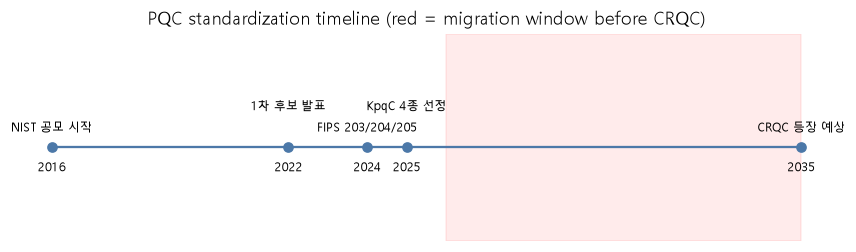

In [25]:
# NIST 표준화 타임라인
fig, ax = plt.subplots(figsize=(8, 2.4))
events = [(2016, 'NIST 공모 시작'), (2022, '1차 후보 발표'), (2024, 'FIPS 203/204/205'),
          (2025, 'KpqC 4종 선정'), (2035, 'CRQC 등장 예상')]
xs = [e[0] for e in events]
ax.plot(xs, [0]*len(xs), '-o', color='#4C78A8')
for k, (x, label) in enumerate(events):
    # 연도가 촘촘한 구간(2022~2025)의 라벨 겹침을 피하려고 위/아래 번갈아 배치
    ax.annotate(label, (x, 0), textcoords='offset points',
                xytext=(0, 10 if k % 2 == 0 else 24), ha='center', fontsize=8, rotation=0)
    ax.annotate(str(x), (x, 0), textcoords='offset points', xytext=(0, -16), ha='center', fontsize=8)
ax.axvspan(2026, 2035, alpha=0.08, color='red')
ax.set_ylim(-0.5, 0.6); ax.axis('off')
ax.set_title('PQC standardization timeline (red = migration window before CRQC)')
plt.tight_layout(); plt.show()

위 시간선에서 점 하나가 표준화의 큰 사건 하나이고, 오른쪽 붉은 음영이
**CRQC(암호학적으로 유의미한 양자컴퓨터 — 현재 암호를 실제로 깰 수 있는 수준의 양자컴퓨터)
등장 전까지 남은 전환 기간**입니다.

- 2016년 NIST 공모 시작 → 2022년 1차 후보 발표 → 2024년 FIPS 203/204/205 확정 →
  2025년 한국 KpqC 4종 선정.
- 2035년이 CRQC 등장 예상 시점이며, 2024·2025처럼 연도가 촘촘한 구간은 라벨을 위아래로 나눠 표시했습니다.

> **표준을 "기다리는" 시대는 2024~2025년에 끝났습니다.** 지금은 붉은 음영 구간,
> 즉 전환의 창(migration window — 이사 갈 수 있는 기간) 안에 있습니다.
> 모스카 부등식("비밀을 지켜야 하는 기간 + 갈아타는 데 걸리는 기간 > 양자컴퓨터가 오기까지
> 남은 기간이면 이미 늦은 것") 관점에서, 오래 지켜야 하는 기밀 데이터에게는
> 이미 빠듯한 시간입니다. "표준이 아직 없어서"는 더 이상 전환을 미룰 이유가 되지 않습니다.


## 3. 실측 크기 비교 (축소 파라미터)

이 시리즈의 알고리즘 노트북들은 **교육용으로 크기를 확 줄인 파라미터**로 구현했기 때문에
절대 크기는 실제 표준보다 훨씬 작습니다. 하지만 **상대적인 경향** —
"격자 KEM은 아담하고, 해시 서명과 코드 키는 크다" — 은 실제 표준과 같은 방향입니다.
축소 모형으로도 건물들의 높이 비율은 비교할 수 있는 것과 같습니다.

아래 셀은 통합본 실행 시 각 알고리즘 절이 기록한 실측값을 `METRICS`에 등록하여,
분리 실행에서도 종합 비교 그래프가 동일하게 재현되도록 하는 보완 셀입니다.


In [ ]:
# 🔗 [분리 노트북 보완] 아래 종합 비교 셀은 각 알고리즘 절이 기록한 METRICS를 사용합니다.
# 분리 실행 시에도 같은 그래프가 그려지도록, 통합 노트북 v3 실행 시 실측된 값을 등록합니다.
for _name, _kv in {
    'Regev/LWE':             {'pk_bytes': 2304, 'ct_bytes': 65},
    'ML-KEM (Kyber)':        {'pk_bytes': 768,  'ct_bytes': 384, 'ss_bytes': 32},
    'ML-DSA (Dilithium)':    {'pk_bytes': 768,  'sig_bytes': 384},
    'SLH-DSA (SPHINCS+)':    {'pk_bytes': 32,   'sig_bytes': 4194},
    'Code-based (McEliece)': {'pk_bits': 28,    'ct_bits': 7},
}.items():
    METRICS.setdefault(_name, _kv)
print('통합 노트북 실측값 등록 완료:', list(METRICS))

### 3-1. 유형별 공개키·출력 크기 그래프

등록된 `METRICS`에서 다섯 구현(Kyber, Dilithium, SPHINCS+, McEliece, Regev)의
공개키 크기와 암호문/서명 크기를 꺼내, 로그 스케일(눈금 한 칸 = 10배) 막대그래프로 나란히 비교합니다.


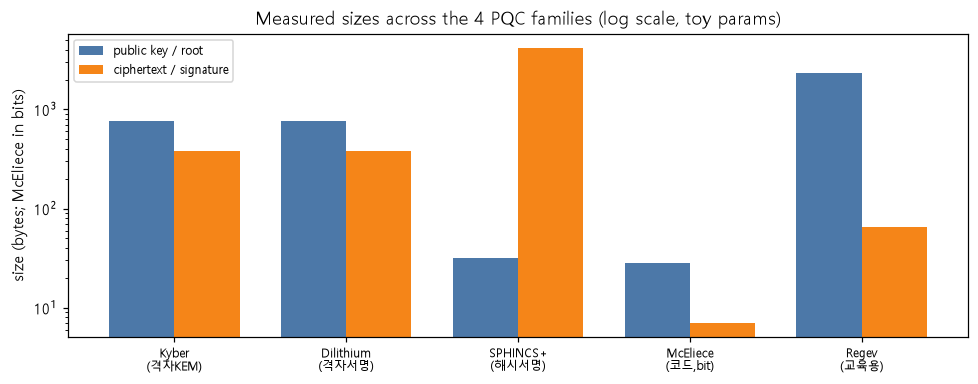

In [26]:
def g(name, key, default=0): return METRICS.get(name, {}).get(key, default) or 0
items = [
    ('Kyber\n(격자KEM)',    g('ML-KEM (Kyber)','pk_bytes'),     g('ML-KEM (Kyber)','ct_bytes')),
    ('Dilithium\n(격자서명)', g('ML-DSA (Dilithium)','pk_bytes'), g('ML-DSA (Dilithium)','sig_bytes')),
    ('SPHINCS+\n(해시서명)', g('SLH-DSA (SPHINCS+)','pk_bytes'), g('SLH-DSA (SPHINCS+)','sig_bytes')),
    ('McEliece\n(코드,bit)', g('Code-based (McEliece)','pk_bits'), g('Code-based (McEliece)','ct_bits')),
    ('Regev\n(교육용)',     g('Regev/LWE','pk_bytes'),           g('Regev/LWE','ct_bytes')),
]
names = [i[0] for i in items]; pk = [i[1] for i in items]; out = [i[2] for i in items]
x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(x - w/2, pk, w, label='public key / root', color='#4C78A8')
ax.bar(x + w/2, out, w, label='ciphertext / signature', color='#F58518')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel('size (bytes; McEliece in bits)'); ax.set_yscale('log')
ax.set_title('Measured sizes across the 4 PQC families (log scale, toy params)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

이 그래프는 직접 만든 4대 유형 구현들의 공개키(파란 막대)와 암호문/서명(주황 막대) 크기입니다.
세로축이 **로그 스케일** — 눈금 한 칸 차이가 10배 차이 — 라는 점에 주의해서 읽어야 합니다.

- **SPHINCS+(해시 서명)** 의 주황 막대가 유독 높습니다(서명 4,194바이트) —
  "해시함수 하나만 믿겠다"는 보수성의 대가가 큰 서명 크기입니다. 안전벨트를 여러 겹 매는 대신
  움직임이 둔해지는 셈입니다.
- **격자 계열(Kyber·Dilithium)** 은 공개키 768바이트, 암호문/서명 384바이트로 균형이 좋습니다.
  격자가 표준의 주력이 된 이유가 이 "균형"입니다.
- **McEliece** 막대는 단위가 **비트**(다른 막대는 바이트, 1바이트 = 8비트)인 교육용 초소형
  파라미터이므로, 막대 높이를 다른 것과 직접 비교하면 안 됩니다.
- **Regev(교육용 LWE)** 는 공개키 2,304바이트로, 다항식 압축(링 구조) 없이 행렬을 통째로 쓰면
  키가 커진다는 점을 보여 줍니다.

> **핵심은 상대적 경향입니다**: 격자는 균형, 해시는 서명이 큼, 코드는 키가 큼.
> 이 경향은 실제 표준 파라미터에서도 똑같이 나타나며, 그래서 유형별로 쓰임새가 갈립니다.
> 실무에서 물어야 할 질문은 "어떤 PQC가 최고인가"가 아니라
> **"우리 시스템의 병목(통신 대역폭? 저장 공간? 서명 횟수?)이 무엇인가"** 입니다.
> 병목에 맞는 알고리즘을 고르는 것이 정답입니다.


## 4. 하이브리드 전환과 크립토 어질리티

PQC는 아직 **역사가 짧은 수학적 가정** 위에 서 있습니다. 수십 년간 공격을 버텨 온 RSA/ECC와 달리,
약점이 갑자기 발견될 가능성을 배제할 수 없습니다. 실제로 NIST 공모 후보였던 SIKE는
공모가 진행되는 도중에 일반 컴퓨터로 깨졌습니다. 그래서 전환기의 정석은 **하이브리드**,
즉 **현관문에 자물쇠를 두 개 다는 것**입니다.

> 오래 검증된 고전 자물쇠(ECDH)와 새 양자내성 자물쇠(Kyber)를 **동시에** 걸고,
> 두 쪽에서 나온 비밀값을 **KDF(Key Derivation Function, 키 유도 함수 — 여러 재료를 섞어
> 최종 열쇠를 뽑아내는 믹서)** 로 결합합니다.
> 도둑이 두 자물쇠를 **모두** 따야만 문이 열리므로, **둘 중 하나만 안전해도** 최종 키는 지켜집니다.

**크립토 어질리티(crypto-agility, 암호 민첩성)** 는 알고리즘을 코드 깊숙이 못 박지 않고
**갈아 끼울 수 있는 부품(모듈)으로 설계하는 능력**입니다. 전구 소켓을 표준화해 두면
어떤 전구든 갈아 끼울 수 있듯, 표준이 바뀌어도 최소 비용으로 교체할 수 있습니다.

### 4-1. 하이브리드 KEM 구현과 공격 시나리오 검증

아래 셀은 개념용 소형 DH(고전 파트)와 mini-Kyber(PQC 파트)의 공유비밀을 KDF로 결합하는
하이브리드 KEM을 구성하고, (1) 정상 상황에서 양쪽의 결합키가 일치하는지,
(2) 고전 또는 PQC 한쪽이 깨져도 공격자가 결합키를 얻지 못하는지 검증합니다.
`kyber_keygen` 등은 통합본의 mini-Kyber 구현을 재사용하므로, 단독 실행 시에는
Kyber 노트북의 함수 정의가 먼저 필요합니다.


In [27]:
# ③④ 하이브리드 KEM = KDF( 고전 공유비밀 || PQC 공유비밀 )
P, GEN = 467, 2                                    # 개념용 소형 DH (실제로는 ECDH/X25519)
def dh_keypair(rng): a = int(rng.integers(2, P-1)); return a, pow(GEN, a, P)
def dh_shared(their_pub, my_priv): return pow(their_pub, my_priv, P)
def kdf(cls_secret, pqc_secret): return H(cls_secret.to_bytes(2,'big') + pqc_secret)

# 고전 파트
a_priv, a_pub = dh_keypair(RNG)
b_priv, b_pub = dh_keypair(RNG)
ss_cls_A = dh_shared(b_pub, a_priv)
ss_cls_B = dh_shared(a_pub, b_priv)
# PQC 파트 (5절의 mini-Kyber 재사용)
pk_k, sk_k = kyber_keygen(RNG)
ct_k, ss_pqc_A = kyber_encaps(pk_k, RNG)
ss_pqc_B = kyber_decaps(sk_k, ct_k)
# 결합
key_A = kdf(ss_cls_A, ss_pqc_A)
key_B = kdf(ss_cls_B, ss_pqc_B)
print('정상: 하이브리드 결합키 일치         :', key_A == key_B)

# 공격 시나리오 A: 고전(ECDH)이 양자컴(Shor)에 뚫림 → 공격자가 ss_cls 를 알아냄
attacker_key = kdf(ss_cls_A, RNG.bytes(32))       # PQC 몫은 추측할 수밖에 없음
print('고전이 뚫려도 공격자 키 불일치(PQC방어):', attacker_key != key_A)
# 공격 시나리오 B: 미래에 PQC가 깨짐 → 공격자가 ss_pqc 를 알아냄
attacker_key2 = kdf(int(RNG.integers(2, P-1)), ss_pqc_A)  # 고전 몫은 추측
print('PQC가 깨져도 공격자 키 불일치(고전방어):', attacker_key2 != key_A)
print('\n→ 하이브리드: 두 축 중 하나만 살아 있어도 최종 키는 안전.')

정상: 하이브리드 결합키 일치         : True
고전이 뚫려도 공격자 키 불일치(PQC방어): True
PQC가 깨져도 공격자 키 불일치(고전방어): True

→ 하이브리드: 두 축 중 하나만 살아 있어도 최종 키는 안전.


실행 결과 세 줄이 모두 `True`입니다. 세 가지 시나리오를 각각 검증한 결과입니다.

1. **정상 시나리오**: 양측이 각자 계산한 하이브리드 결합키가 일치합니다 — 이중 자물쇠가
   정상 작동합니다.
2. **고전이 뚫린 시나리오**(양자컴퓨터의 Shor 알고리즘으로 DH 비밀이 노출된 상황):
   공격자는 나머지 PQC 몫을 알 수 없어 결합키를 얻지 못합니다 — **PQC 자물쇠가 막아 줍니다.**
3. **PQC가 깨진 시나리오**(새 수학에서 약점이 발견된 상황): 반대로 고전 몫이 남아 있어
   역시 결합키를 얻지 못합니다 — **고전 자물쇠가 막아 줍니다.**

> **두 자물쇠 중 하나만 살아 있어도 문은 열리지 않습니다.** 이것이 하이브리드의 이중 안전 원리입니다.

### 4-2. 결합 개념 시각화

아래 셀은 고전 공유비밀과 PQC 공유비밀이 KDF(믹서)에서 합쳐져 최종 키가 되는 흐름을
개념도로 그리고, 검증 결과를 `METRICS`에 기록합니다.


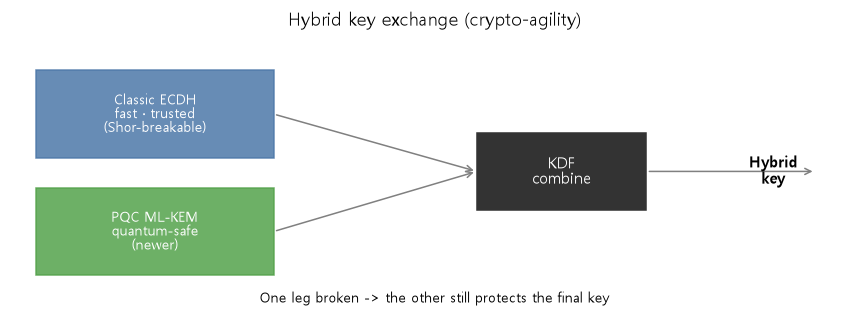

In [28]:
fig, ax = plt.subplots(figsize=(8, 3)); ax.axis('off')
boxes = [(0.05,'Classic ECDH\n(fast, trusted)\nbut Shor-breakable','#4C78A8'),
         (0.05,'',''),
         (0.38,'PQC ML-KEM\n(quantum-safe)\nbut newer','#54A24B')]
ax.add_patch(plt.Rectangle((0.03,0.55),0.28,0.32, color='#4C78A8', alpha=.85))
ax.text(0.17,0.71,'Classic ECDH\nfast · trusted\n(Shor-breakable)',ha='center',va='center',color='white',fontsize=9)
ax.add_patch(plt.Rectangle((0.03,0.12),0.28,0.32, color='#54A24B', alpha=.85))
ax.text(0.17,0.28,'PQC ML-KEM\nquantum-safe\n(newer)',ha='center',va='center',color='white',fontsize=9)
ax.annotate('',xy=(0.55,0.5),xytext=(0.31,0.71),arrowprops=dict(arrowstyle='->',color='gray'))
ax.annotate('',xy=(0.55,0.5),xytext=(0.31,0.28),arrowprops=dict(arrowstyle='->',color='gray'))
ax.add_patch(plt.Rectangle((0.55,0.36),0.2,0.28, color='#333'))
ax.text(0.65,0.5,'KDF\ncombine',ha='center',va='center',color='white',fontsize=10)
ax.annotate('',xy=(0.95,0.5),xytext=(0.75,0.5),arrowprops=dict(arrowstyle='->',color='gray'))
ax.text(0.9,0.5,'Hybrid\nkey',ha='center',va='center',fontsize=10,weight='bold')
ax.text(0.5,0.02,'One leg broken -> the other still protects the final key',ha='center',fontsize=9,style='italic')
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.title('Hybrid key exchange (crypto-agility)'); plt.tight_layout(); plt.show()
log_metric('Hybrid', match=bool(key_A==key_B), classical_break_safe=bool(attacker_key!=key_A))

개념도에서 왼쪽 두 상자 — 고전 ECDH(파랑: 수십 년 검증됐지만 양자컴퓨터의 Shor 알고리즘에는
깨짐)와 PQC ML-KEM(초록: 양자에도 안전하지만 상대적으로 신생) — 가 각각 만든 공유비밀이
가운데 KDF(믹서)로 **모두** 들어가야만 오른쪽의 최종 하이브리드 키가 나옵니다.
다리 두 개로 서 있는 구조이므로, 한쪽 다리가 부러져도 최종 키는 버팁니다.
바로 위 셀의 검증 결과(정상 시 일치, 한쪽 노출 시 공격자 실패)가 그 증거입니다.

### 4-3. 실무 적용성 판단

- **측정**: 정상일 때는 결합키가 일치하고, 고전 또는 PQC 한쪽이 뚫려도 공격자는 결합키를
  얻지 못했습니다 — 하이브리드의 이중 안전을 코드로 확인했습니다.
- **표준·현장**: TLS 1.3(웹의 https 통신 규약)의 **X25519+ML-KEM 하이브리드**가 이미
  크롬 브라우저·클라우드플레어 등에서 실서비스로 배포 중입니다. 즉 여러분이 오늘 연 웹페이지도
  이미 이 이중 자물쇠를 쓰고 있을 수 있습니다. 국내 통신사도 PQC+QKD 하이브리드망을
  구축하고 있습니다.
- **원칙**: 전환기에는 하이브리드가 정석이며, **크립토 어질리티**(부품처럼 교체 가능한 설계)로
  언제든 알고리즘을 갈아 끼울 수 있게 해 두어야 합니다.

> 전환기의 정답은 "PQC로의 즉시 교체"가 아니라 **"고전+PQC 하이브리드"** 입니다.
> 지금의 인터넷이 실제로 이 방식으로 갈아타는 중입니다.


## 5. 실제 전환은 어떻게 — 마이그레이션 4단계

시스템 전체의 암호를 하루아침에 다 바꿀 수는 없습니다. 큰 건물의 배관 전체를 한 번에 교체할 수
없는 것과 같습니다. **한 번에 다 바꾸지 않고, 중요한 것부터 단계적으로** 옮기는 것이 원칙입니다.

1. **자산 식별(Discovery, 목록 만들기)**: 우리 시스템이 어디서 어떤 암호(RSA/ECC/AES 등)를
   쓰는지 전부 목록으로 만듭니다. 이 목록을 암호 인벤토리 또는 **CBOM(암호 자재 명세서 —
   건축 자재 목록의 암호판)** 이라고 합니다. 어디에 뭐가 쓰였는지 모르면 바꿀 수도 없습니다.
2. **우선순위(Prioritize)**: 데이터의 **기밀 수명(얼마나 오래 비밀이어야 하나) × 민감도**로
   순서를 정합니다(모스카 부등식). 10년 뒤에도 비밀이어야 하는 장기 기밀 데이터가 최우선입니다.
3. **파일럿(Pilot, 시범 적용)**: 중요 시스템 한두 곳에 하이브리드 구성을 먼저 적용해
   성능·호환성 문제를 미리 확인합니다.
4. **단계적 확대(Scale)**: 시범에서 검증된 구성부터 전면 확대하고, 크립토 어질리티로
   유지·교체를 이어 갑니다.

**전환이 어려운 이유**도 분명합니다: PQC는 키·데이터가 커서 생기는 성능·네트워크 부담,
기존 인프라와의 호환성 문제, 교체 비용, 아직 정비 중인 세부 가이드라인 등입니다.
그래서 CRQC(암호를 깰 수 있는 양자컴퓨터) 예상 시점에서 **거꾸로 계산해 지금 시작**하는 것이
핵심입니다 — 이사 갈 날짜가 정해져 있으면 짐 싸기는 미리 시작해야 합니다.

> 전환은 **"목록 만들기 → 중요한 것부터 → 시범 → 확대"의 4단계**이며,
> 완벽한 계획보다 빠른 시작이 중요합니다.


## 6. 핵심 정리와 용어

지금까지 시리즈 전체의 내용을 네 문장으로 압축하면 다음과 같습니다.

1. **양자컴퓨터가 기존 암호를 위협합니다** — Shor 알고리즘이 RSA·ECC가 기대고 있는 수학 문제
   (소인수분해·이산로그)를 빠르게 풀어 버립니다. 대칭키 암호(AES 등)는 Grover 알고리즘으로
   안전성이 절반으로 줄지만, 키 길이를 2배로 늘리면 대응할 수 있습니다.
2. **지금 준비해야 합니다** — "지금 훔쳐 두고 나중에 양자컴퓨터로 푸는" HNDL 공격과
   모스카 부등식에 따르면, 오래 지켜야 하는 기밀 데이터는 양자컴퓨터가 오기 전인
   지금도 이미 위험합니다.
3. **PQC가 소프트웨어 해법입니다** — 격자·해시·코드·다변수 4대 유형을 직접 구현해
   동작을 확인했고, 표준은 NIST FIPS 203/204/205와 한국 KpqC 4종으로 이미 확정되었습니다.
4. **QKD로 보완하고 단계적으로 전환합니다** — 물리 법칙 기반 QKD(BB84)로 도청을 탐지하고,
   하이브리드(이중 자물쇠)·크립토 어질리티(교체 가능한 설계)로 중요한 것부터 옮깁니다.

### 용어 정리

| 용어 | 뜻 |
|---|---|
| RSA·ECC | 현재 널리 쓰는 공개키 암호 (Shor에 취약) |
| Shor / Grover | 공개키를 깨는 / 대칭키를 절반 약화시키는 양자 알고리즘 |
| HNDL | 지금 수집·나중에 복호하는 공격 (Harvest Now, Decrypt Later) |
| PQC | 양자내성암호. 소프트웨어·수학 난제 기반 |
| 격자(Lattice)·LWE | PQC의 대표 수학 기반 (최단벡터·오차 학습) |
| CRYSTALS-Kyber / -Dilithium | NIST 표준 KEM/서명 (표준명 ML-KEM / ML-DSA) |
| SPHINCS+ / Falcon / HQC | 해시 서명(SLH-DSA) / 소형 격자 서명(FN-DSA) / 코드 KEM |
| KpqC | 한국형 PQC (NTRU+, SMAUG-T, HAETAE, AIMer) |
| QKD / BB84 | 물리 하드웨어 기반 양자 키 분배 / 그 대표 프로토콜 |
| 하이브리드 | 고전+PQC 병행으로 한쪽이 뚫려도 방어 (이중 자물쇠) |
| 크립토 어질리티 | 알고리즘을 쉽게 교체 가능하게 설계하는 능력 |


## 연습문제

아래 질문에 스스로 답해 본 뒤, 해당 장으로 돌아가 확인해 보세요.

1. **PQC와 양자컴퓨터**: PQC를 쓰려면 양자컴퓨터가 필요할까요? PQC가 "양자"라는 이름을
   달고 있는 진짜 이유는 무엇인가요? (힌트: 양자컴퓨터로 "만드는" 암호가 아니라
   양자컴퓨터를 "버티는" 암호입니다.) (1장)
2. **4대 유형**: PQC의 4가지 유형을 나열하고, 현재 표준의 중심이 어느 유형인지,
   나머지 유형들이 왜 함께 표준화되는지("계란을 한 바구니에 담지 않기") 설명해 보세요. (1~2장)
3. **PQC vs QKD**: 두 기술의 근본적인 차이(소프트웨어/수학 vs 물리 하드웨어)와,
   왜 경쟁이 아니라 보완 관계인지 설명해 보세요. (6장)
4. **HNDL**: 오늘 도청·수집된 암호문이 왜 "지금 이미" 위험한지, 모스카 부등식과 연결해
   설명해 보세요. (2장, 5장)
5. **하이브리드 확장(코드 실습)**: 4-1의 `kdf` 함수에 세 번째 재료(예: 미리 나눠 가진
   비밀값 PSK)를 추가해 자물쇠 3개짜리 3중 하이브리드로 확장하고, 어느 한 재료가 노출되어도
   결합키가 안전한지 같은 방식으로 검증해 보세요.
6. **크기 비교 확장(코드 실습)**: 다른 알고리즘 노트북에서 `log_metric`으로 기록한 값을
   3-1의 `items` 목록에 추가하여, 더 많은 알고리즘을 한 그래프에서 비교해 보세요.


## 요약

- PQC 4대 유형은 **격자·해시·코드·다변수**이며, 격자가 주력이고 나머지는
  "격자가 깨질 경우"에 대비해 바탕 수학을 분산하는 백업이다.
- 표준은 이미 확정되었다 — NIST **ML-KEM(FIPS 203)·ML-DSA(FIPS 204)·SLH-DSA(FIPS 205)**
  (FN-DSA는 FIPS 206 예정, HQC 추가선정), 한국 KpqC **NTRU+·SMAUG-T·HAETAE·AIMer** 4종.
  이제는 "골라 쓰는" 단계다.
- 실측 크기 비교에서 **격자는 균형, 해시는 서명이 큼, 코드는 키가 큼**이라는 경향을
  확인했으며, 이는 실제 표준과 같은 방향이다. 선택 기준은 "최고의 알고리즘"이 아니라
  "우리 시스템의 병목"이다.
- **하이브리드 KEM** = KDF(고전 공유비밀 ∥ PQC 공유비밀), 즉 자물쇠 두 개를 동시에 걸기.
  둘 중 하나만 안전해도 최종 키가 지켜짐을 코드로 검증했다.
- 전환은 **목록 만들기(자산 식별) → 우선순위 → 시범(파일럿) → 단계적 확대**의 4단계로
  진행하며, 크립토 어질리티(교체 가능한 설계)가 그 토대다.

> 위협(HNDL)은 이미 시작되었고, 해법(PQC 표준)도 이미 나와 있습니다 — 남은 것은
> 각자의 시스템을 언제, 어떻게 옮기느냐는 실행의 문제입니다. 더 공부하려면
> NIST PQC 표준 문서(FIPS 203/204/205), KISA·KpqC 연구단 자료, Open Quantum Safe(`liboqs`)
> 프로젝트와 각 알고리즘의 원논문을 참고하세요.
